In [1]:
# ========================================
# AfyaMetrix Anomaly Detection Module
# Notebook: 02_anomaly_detection.ipynb
# ========================================

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports successful")
print("🔍 Building AfyaMetrix Anomaly Detection Engine...")

✅ Imports successful
🔍 Building AfyaMetrix Anomaly Detection Engine...


In [2]:
# ========================================
# LOAD THE SIMULATED DATASET
# ========================================

# Load the data we generated in the previous notebook
df = pd.read_csv(r"C:\Users\hassa\afyametrix\data\raw\africa_health_simulated.csv")

# Convert date column from string to actual datetime
# This is critical — without this, we can't do time-based calculations
df['date'] = pd.to_datetime(df['date'])

# Sort by country, region, disease, then date
# This ensures our rolling calculations work correctly
df = df.sort_values(['country', 'region', 'disease', 'date']).reset_index(drop=True)

print(f"✅ Data loaded: {len(df):,} records")
print(f"   Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nFirst 3 rows:")
print(df[['date', 'country', 'region', 'disease', 'cases']].head(3))

✅ Data loaded: 497,080 records
   Date range: 2023-01-01 to 2024-12-31

First 3 rows:
        date country  region  disease  cases
0 2023-01-01     DRC  Bukavu  Cholera     94
1 2023-01-02     DRC  Bukavu  Cholera    106
2 2023-01-03     DRC  Bukavu  Cholera    160


In [3]:
# ========================================
# LAYER 1: Z-SCORE ANOMALY DETECTION
# ========================================
# 
# What is a Z-score?
# It measures how many standard deviations a value is from the mean.
# 
# Formula: Z = (today's cases - rolling average) / rolling std deviation
#
# If Z > 2.0: cases are unusually HIGH (potential outbreak)
# If Z < -2.0: cases are unusually LOW (possible reporting failure)
# 
# We use a 14-day ROLLING window — meaning we compare today
# against the past 14 days, not the entire year.
# This makes it sensitive to recent changes, not long-term averages.

def calculate_zscore_anomalies(df, window=14, threshold=2.0):
    """
    Calculates Z-score for each row based on a rolling window.
    
    Parameters:
    - df: your dataframe
    - window: how many past days to use as baseline (14 days)
    - threshold: how many std deviations = anomaly (2.0 = 95% confidence)
    
    Returns dataframe with new anomaly columns added.
    """
    
    print(f"⚙️  Calculating Z-scores (window={window} days, threshold=±{threshold})...")
    
    # We process each country+region+disease combination separately
    # because Nairobi malaria has nothing to do with Lagos cholera
    groups = df.groupby(['country', 'region', 'disease'])
    
    results = []
    
    for name, group in groups:
        # Sort by date within this group
        group = group.copy().sort_values('date')
        
        # Calculate rolling mean and std over the past 14 days
        # min_periods=3 means we need at least 3 days of data before calculating
        rolling_mean = group['cases'].rolling(window=window, min_periods=3).mean()
        rolling_std = group['cases'].rolling(window=window, min_periods=3).std()
        
        # Calculate Z-score for each day
        # Where std is 0 (no variation), set Z to 0 to avoid division errors
        zscore = np.where(
            rolling_std > 0,
            (group['cases'] - rolling_mean) / rolling_std,
            0
        )
        
        group['rolling_mean_14d'] = rolling_mean.round(2)
        group['rolling_std_14d'] = rolling_std.round(2)
        group['zscore'] = np.round(zscore, 3)
        
        # Flag as anomaly if Z-score exceeds our threshold
        group['zscore_anomaly'] = np.abs(zscore) > threshold
        
        # Classify the direction of the anomaly
        group['zscore_direction'] = np.where(
            zscore > threshold, 'HIGH',      # unusual spike
            np.where(zscore < -threshold, 'LOW', 'NORMAL')  # unusual drop
        )
        
        results.append(group)
    
    # Combine all groups back into one dataframe
    df_result = pd.concat(results).sort_values(
        ['country', 'region', 'disease', 'date']
    ).reset_index(drop=True)
    
    # Count and report
    anomaly_count = df_result['zscore_anomaly'].sum()
    anomaly_pct = (anomaly_count / len(df_result) * 100).round(2)
    
    print(f"✅ Z-score calculation complete")
    print(f"   Anomalies detected: {anomaly_count:,} ({anomaly_pct}% of all records)")
    print(f"   HIGH spikes: {(df_result['zscore_direction'] == 'HIGH').sum():,}")
    print(f"   LOW drops:   {(df_result['zscore_direction'] == 'LOW').sum():,}")
    
    return df_result

# Run Layer 1
df = calculate_zscore_anomalies(df, window=14, threshold=2.0)

⚙️  Calculating Z-scores (window=14 days, threshold=±2.0)...
✅ Z-score calculation complete
   Anomalies detected: 24,090 (4.85% of all records)
   HIGH spikes: 19,554
   LOW drops:   4,536


In [6]:
# ========================================
# LAYER 2: ISOLATION FOREST
# ========================================
#
# What is Isolation Forest?
# It's a machine learning algorithm that detects outliers by asking:
# "How easy is it to isolate this data point from the rest?"
#
# Normal points: hard to isolate (surrounded by similar points)
# Anomalies: easy to isolate (they stand alone)
#
# Why use it ALONGSIDE Z-score?
# Z-score only looks at one variable (case count)
# Isolation Forest looks at MULTIPLE variables simultaneously:
# - case count
# - rate of change
# - relationship to rolling average
# - seasonal position
# This catches complex patterns that Z-score misses.

def calculate_isolation_forest_anomalies(df, contamination=0.05):
    """
    Applies Isolation Forest to detect multi-dimensional anomalies.
    
    Parameters:
    - df: dataframe (must already have Z-score columns from Layer 1)
    - contamination: expected proportion of anomalies (5% = 0.05)
    
    Returns dataframe with Isolation Forest anomaly columns added.
    """
    
    print(f"⚙️  Running Isolation Forest (contamination={contamination})...")
    
    groups = df.groupby(['country', 'region', 'disease'])
    results = []
    
    for name, group in groups:
        group = group.copy().sort_values('date')
        
        # Feature engineering — we give the model more than just raw cases
        # These derived features help it understand the DATA SHAPE not just values
        
        # 1. Case growth rate: how fast are cases changing day-over-day? 
        # Adjusted to avoid division by zero (Infinity error)
        group['growth_rate'] = (group['cases'] - group['cases'].shift(1)) / (group['cases'].shift(1) + 1)
        group['growth_rate'] = group['growth_rate'].fillna(0)
        
        # 2. Cases relative to rolling mean: are we above or below recent average?
        group['cases_vs_mean'] = np.where(
            group['rolling_mean_14d'] > 0,
            group['cases'] / group['rolling_mean_14d'],
            1.0
        )
        
        # 3. Day of year: captures seasonal position (day 1-365)
        group['day_of_year'] = group['date'].dt.dayofyear
        
        # 4. Week of year: weekly patterns
        group['week_of_year'] = group['date'].dt.isocalendar().week.astype(int)
        
        # Select features for the model
        features = ['cases', 'growth_rate', 'cases_vs_mean', 
                   'zscore', 'day_of_year']

        # --- THE SAFETY LINE ---
        # Fill NaNs and replace any accidental Infinity values before scaling
        feature_data = group[features].fillna(0)
        feature_data.replace([np.inf, -np.inf], 0, inplace=True)
        
        # Only run if we have enough data points (at least 20 days)
        if len(feature_data) < 20:
            group['if_anomaly'] = False
            group['if_score'] = 0.0
            results.append(group)
            continue
        
        # Standardize features — Isolation Forest works better when
        # all features are on the same scale (mean=0, std=1)
        scaler = StandardScaler()
        feature_scaled = scaler.fit_transform(feature_data)
        
        # Run the model
        # n_estimators=100: uses 100 decision trees (more = more accurate)
        # random_state=42: reproducible results
        iso_forest = IsolationForest(
            n_estimators=100,
            contamination=contamination,
            random_state=42
        )
        
        # fit_predict returns: -1 for anomaly, 1 for normal
        predictions = iso_forest.fit_predict(feature_scaled)
        
        # decision_function gives us a continuous score
        # More negative = more anomalous
        scores = iso_forest.decision_function(feature_scaled)
        
        # Convert -1/1 to True/False
        group['if_anomaly'] = predictions == -1
        
        # Normalize score to 0-1 range (easier to understand)
        # 1.0 = most anomalous, 0.0 = most normal
        min_score, max_score = scores.min(), scores.max()
        if max_score > min_score:
            group['if_score'] = 1 - ((scores - min_score) / (max_score - min_score))
        else:
            group['if_score'] = 0.0
        
        group['if_score'] = group['if_score'].round(3)
        
        results.append(group)
    
    df_result = pd.concat(results).sort_values(
        ['country', 'region', 'disease', 'date']
    ).reset_index(drop=True)
    
    if_anomaly_count = df_result['if_anomaly'].sum()
    print(f"✅ Isolation Forest complete")
    print(f"   Anomalies detected: {if_anomaly_count:,} ({(if_anomaly_count/len(df_result)*100):.2f}% of records)")
    
    return df_result

# Run Layer 2
df = calculate_isolation_forest_anomalies(df, contamination=0.05)

⚙️  Running Isolation Forest (contamination=0.05)...
✅ Isolation Forest complete
   Anomalies detected: 25,160 (5.06% of records)


In [7]:
# ========================================
# COMBINED ANOMALY SCORING
# ========================================
#
# Strategy: An anomaly is MORE credible when BOTH methods agree.
# 
# Confidence levels:
# - BOTH methods flag it → HIGH confidence anomaly
# - Only one method flags it → MEDIUM confidence (worth watching)  
# - Neither flags it → Normal
#
# This reduces false positives — the enemy of trust in any AI system.
# If your system cries wolf too often, health officials ignore it.

def create_combined_anomaly_score(df):
    """
    Combines Z-score and Isolation Forest results into a 
    unified anomaly assessment with confidence levels.
    """
    
    print("⚙️  Combining anomaly signals...")
    
    df = df.copy()
    
    # Combined flag: TRUE only when BOTH methods agree
    df['confirmed_anomaly'] = df['zscore_anomaly'] & df['if_anomaly']
    
    # Confidence score (0-100)
    # Z-score contribution: 40 points max
    # Isolation Forest contribution: 60 points max (it's the smarter model)
    
    # Normalize Z-score to 0-40 range
    zscore_contribution = np.clip(np.abs(df['zscore']) / 5.0, 0, 1) * 40
    
    # IF score contribution: 0-60 range  
    if_contribution = df['if_score'] * 60
    
    df['anomaly_confidence'] = (zscore_contribution + if_contribution).round(1)
    
    # Confidence tier labels
    df['confidence_tier'] = pd.cut(
        df['anomaly_confidence'],
        bins=[0, 30, 60, 80, 100],
        labels=['Low', 'Medium', 'High', 'Critical'],
        include_lowest=True
    )
    
    # Only flag confirmed anomalies that are HIGH direction (spikes, not drops)
    # For outbreak detection, we care about cases going UP, not DOWN
    df['outbreak_alert'] = (
        df['confirmed_anomaly'] & 
        (df['zscore_direction'] == 'HIGH')
    )
    
    # Summary
    print(f"✅ Combined scoring complete")
    print(f"\n📊 Anomaly Summary:")
    print(f"   Z-score anomalies:       {df['zscore_anomaly'].sum():,}")
    print(f"   Isolation Forest:        {df['if_anomaly'].sum():,}")
    print(f"   CONFIRMED (both agree):  {df['confirmed_anomaly'].sum():,}")
    print(f"   🚨 Outbreak alerts:      {df['outbreak_alert'].sum():,}")
    
    print(f"\n📊 Confidence Distribution (confirmed anomalies only):")
    confirmed = df[df['confirmed_anomaly']]
    if len(confirmed) > 0:
        print(confirmed['confidence_tier'].value_counts().to_string())
    
    return df

df = create_combined_anomaly_score(df)

⚙️  Combining anomaly signals...
✅ Combined scoring complete

📊 Anomaly Summary:
   Z-score anomalies:       24,090
   Isolation Forest:        25,160
   CONFIRMED (both agree):  14,165
   🚨 Outbreak alerts:      12,673

📊 Confidence Distribution (confirmed anomalies only):
confidence_tier
High        6133
Medium      5935
Critical    2097
Low            0


🚨 TOP 20 OUTBREAK ALERTS (Highest Confidence):

         date   country           region     disease  cases  rolling_mean_14d  zscore  if_score  anomaly_confidence confidence_tier  times_above_normal
0  2023-07-27       DRC           Bukavu        Mpox    469             75.29   3.470       1.0                87.8        Critical                 6.2
1  2023-09-27       DRC        Kisangani        Mpox    429             72.64   3.469       1.0                87.8        Critical                 5.9
2  2024-12-08       DRC       Lubumbashi        Mpox    511            108.36   3.469       1.0                87.8        Critical                 4.7
3  2023-06-29       DRC       Mbuji-Mayi        Mpox    543             86.86   3.470       1.0                87.8        Critical                 6.3
4  2024-04-11  Ethiopia      Addis Ababa        Mpox    250             36.71   3.471       1.0                87.8        Critical                 6.8
5  2023-12-21  Ethiopia           Amhara

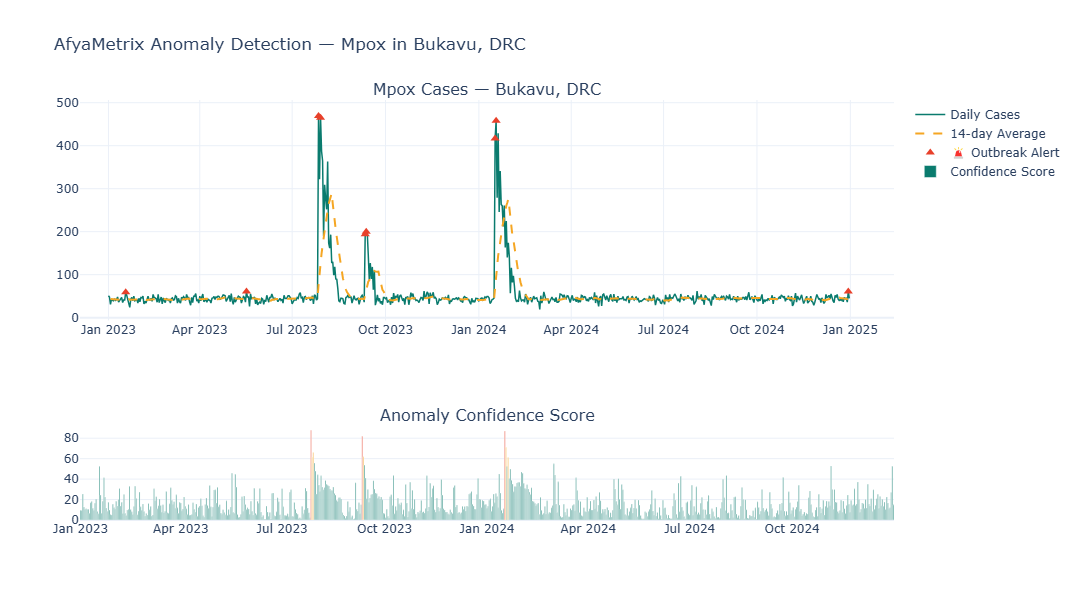

In [10]:
# ========================================
# VIEW TOP ALERTS
# ========================================

# Show the most critical outbreak alerts
print("🚨 TOP 20 OUTBREAK ALERTS (Highest Confidence):\n")

top_alerts = df[df['outbreak_alert']].nlargest(20, 'anomaly_confidence')[
    ['date', 'country', 'region', 'disease', 'cases', 
     'rolling_mean_14d', 'zscore', 'if_score', 
     'anomaly_confidence', 'confidence_tier']
].reset_index(drop=True)

# Add a column showing how many times above normal this is
top_alerts['times_above_normal'] = (
    top_alerts['cases'] / top_alerts['rolling_mean_14d']
).round(1)

print(top_alerts.to_string())

# ========================================
# VISUALIZE ONE OUTBREAK
# ========================================

# Let's visualize the highest confidence alert to see what it looks like
top_alert = top_alerts.iloc[0]
country = top_alert['country']
region = top_alert['region']  
disease = top_alert['disease']

print(f"\n📈 Visualizing: {disease} in {region}, {country}")

# Filter data for just this combination
viz_data = df[
    (df['country'] == country) & 
    (df['region'] == region) & 
    (df['disease'] == disease)
].copy()

# Create the chart
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=[
        f'{disease} Cases — {region}, {country}',
        'Anomaly Confidence Score'
    ],
    row_heights=[0.7, 0.3]
)

# Main case count line
fig.add_trace(
    go.Scatter(
        x=viz_data['date'], 
        y=viz_data['cases'],
        mode='lines',
        name='Daily Cases',
        line=dict(color='#0A7B6E', width=1.5)
    ),
    row=1, col=1
)

# Rolling average line
fig.add_trace(
    go.Scatter(
        x=viz_data['date'],
        y=viz_data['rolling_mean_14d'],
        mode='lines',
        name='14-day Average',
        line=dict(color='#F5A623', width=2, dash='dash')
    ),
    row=1, col=1
)

# Highlight outbreak alert points in red
alerts_viz = viz_data[viz_data['outbreak_alert']]
fig.add_trace(
    go.Scatter(
        x=alerts_viz['date'],
        y=alerts_viz['cases'],
        mode='markers',
        name='🚨 Outbreak Alert',
        marker=dict(color='#E8402A', size=8, symbol='triangle-up')
    ),
    row=1, col=1
)

# Confidence score bar chart
fig.add_trace(
    go.Bar(
        x=viz_data['date'],
        y=viz_data['anomaly_confidence'],
        name='Confidence Score',
        marker_color=np.where(
            viz_data['anomaly_confidence'] > 80, '#E8402A',
            np.where(viz_data['anomaly_confidence'] > 60, '#F5A623', '#0A7B6E')
        )
    ),
    row=2, col=1
)

fig.update_layout(
    height=600,
    title=f'AfyaMetrix Anomaly Detection — {disease} in {region}, {country}',
    template='plotly_white',
    showlegend=True
)

fig.show()

In [11]:
# ========================================
# SAVE PROCESSED DATA WITH ANOMALY FLAGS
# ========================================

save_path = r"C:\Users\hassa\afyametrix\data\processed\africa_health_anomalies.csv"
df.to_csv(save_path, index=False)

print(f"✅ Anomaly data saved to: {save_path}")
print(f"   Total records: {len(df):,}")
print(f"   Columns: {list(df.columns)}")
print(f"\n🎯 Your anomaly detection engine is complete and working.")
print(f"   Z-score (statistical) + Isolation Forest (ML) = production-grade detection")

✅ Anomaly data saved to: C:\Users\hassa\afyametrix\data\processed\africa_health_anomalies.csv
   Total records: 497,080
   Columns: ['date', 'country', 'region', 'disease', 'cases', 'is_outbreak', 'population', 'healthcare_access', 'climate', 'urban_factor', 'seasonal_multiplier', 'rolling_mean_14d', 'rolling_std_14d', 'zscore', 'zscore_anomaly', 'zscore_direction', 'growth_rate', 'cases_vs_mean', 'day_of_year', 'week_of_year', 'if_anomaly', 'if_score', 'confirmed_anomaly', 'anomaly_confidence', 'confidence_tier', 'outbreak_alert']

🎯 Your anomaly detection engine is complete and working.
   Z-score (statistical) + Isolation Forest (ML) = production-grade detection
